In [1]:

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from pathlib import Path

root_path = Path.cwd().parent.absolute()
import sys

sys.path.append(str(root_path))
import os


In [2]:
from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [3]:
from geometry.G_matrix import G_matrix
from functionals.functions import create_potentials
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.interaction_functional_class import InteractionPotential
from functionals.functional import Potential
from flows.anderson_acceleration import anderson_method
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel

In [4]:
# Define the parametric model
dim = 2
parametric_model = ParametricModel(
    parametric_map="resnet",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 2, 50],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.1, 
    ref_density="gaussian",
    scale_factor=1e-1,
)
_,init_params = nnx.split(parametric_model)


In [5]:
key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)

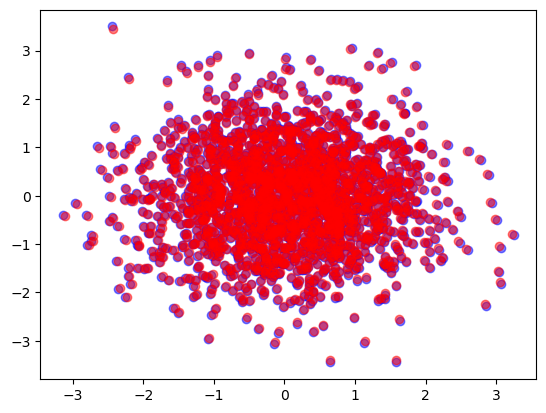

In [6]:
key,subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (2000, dim))
y = parametric_model(samples = z_samples,params=init_params)

plt.scatter(z_samples[:,0],z_samples[:,1],c='blue',alpha=0.5)
plt.scatter(y[:,0],y[:,1],c='red',alpha=0.5)

In [7]:
from functionals.functions import double_well_potential_fn, styblinski_tang_potential_fn, aggregation_potential_fn,zero_potential_fn
linear_potential = LinearPotential(potential_fn= zero_potential_fn, coeff = 1.0)
internal_potential = InternalPotential(functional='entropy', coeff = 1, method= 'hutchinson',prob_dim=dim)
interaction_potential = InteractionPotential(interaction_fn = aggregation_potential_fn, coeff = 1, a = 4, b = 2)

potential = Potential(linear = linear_potential,
                      internal = None,
                      interaction = interaction_potential)

In [10]:
# Anderson parameters
h = 1e-3 # Time step size
m = 8# Number of previous iterates to consider
beta = 1.75 # Damping parameter
max_iterations = 300
tolerance = 1e-4
l2_reg_gamma = 1e-2
n_samples = 10_000  # Monte Carlo sample size

key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, dim))

G_mat_flow = G_matrix(parametric_model)
solver = "cg"  # minres or cg


Starting Anderson-accelerated gradient flow
  n_iterations: 300
  step_size: 0.001
  memory_size: 8
  mixing_parameter: 1.75
------------------------------------------------------------
Iter    0 | Energy: -7.525381e-02 | Residual: 1.580035e-04 | 


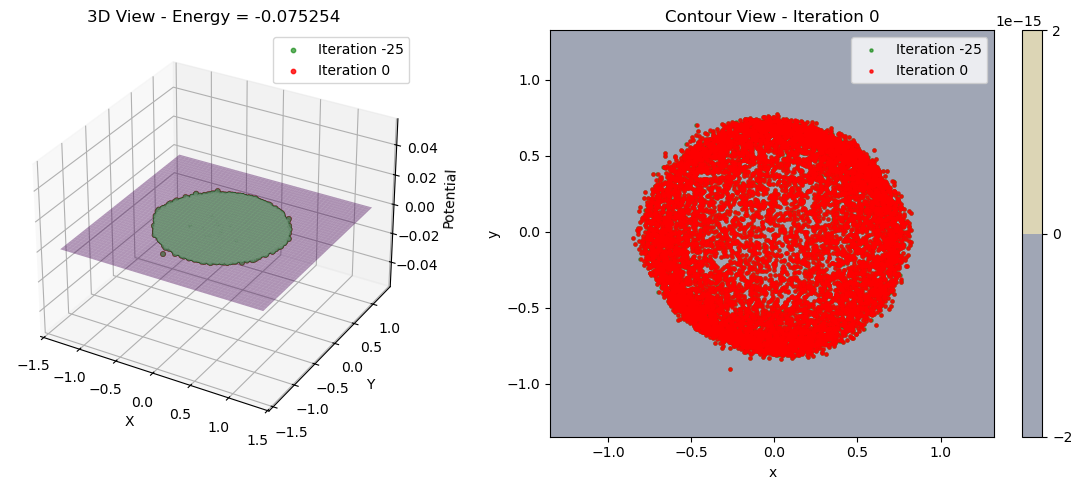

Iter    1 | Energy: -7.536615e-02 | Residual: 1.182625e-04 | 


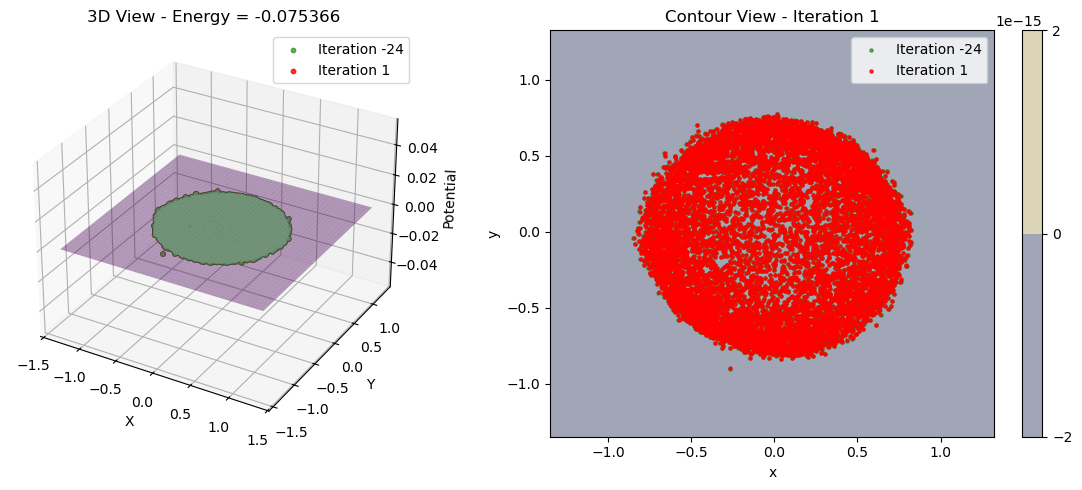

Iter    2 | Energy: -7.540222e-02 | Residual: 1.016561e-04 | 


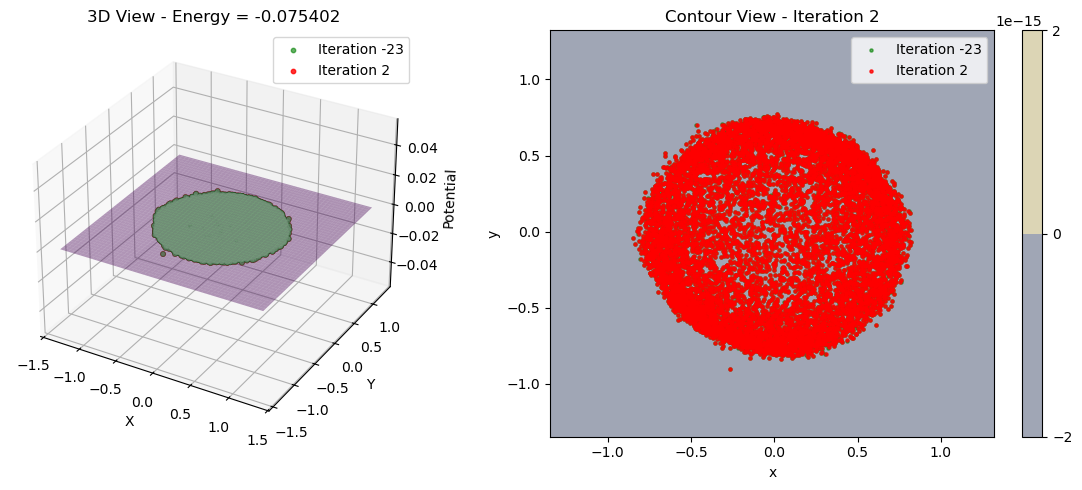

Iter    3 | Energy: -7.546057e-02 | Residual: 1.141855e-04 | 


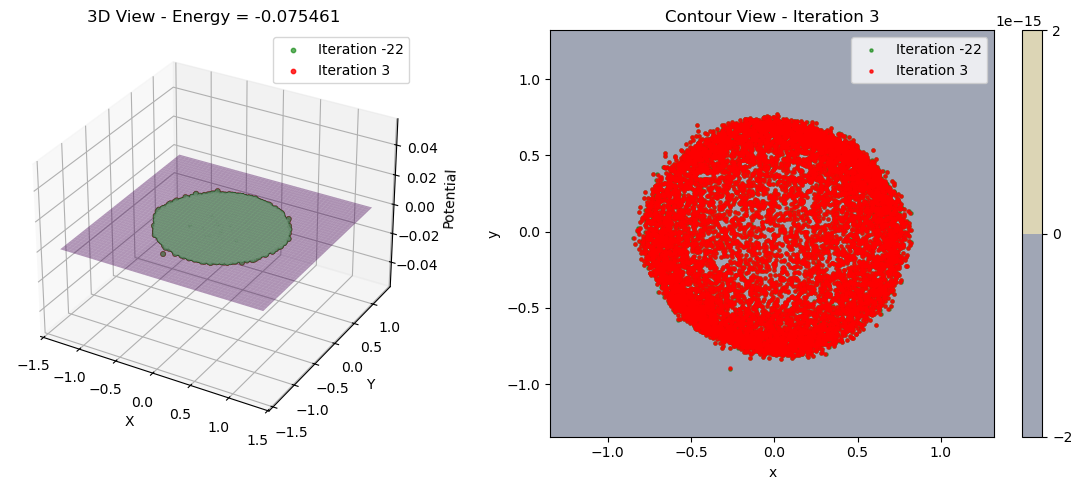

Iter    4 | Energy: -7.549027e-02 | Residual: 9.127415e-05 | 


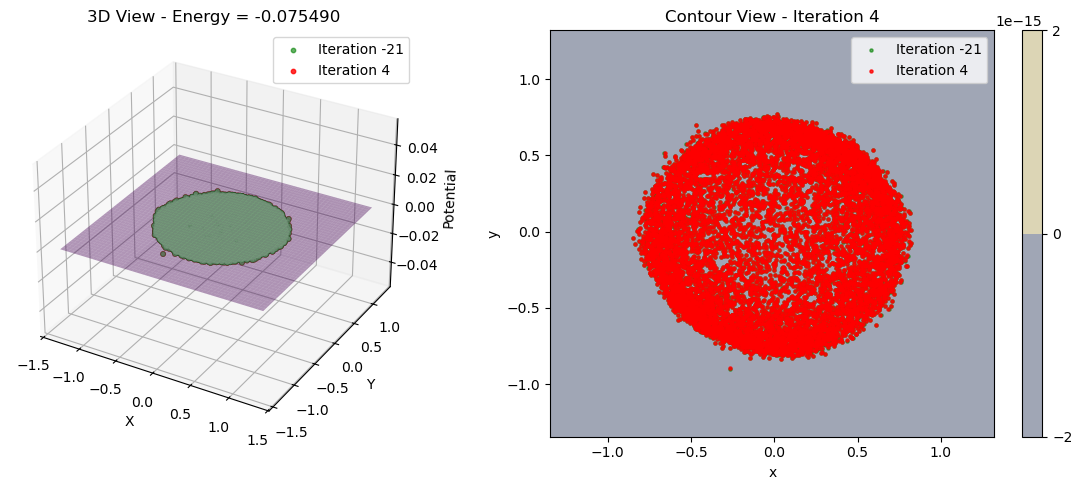

Iter   25 | Energy: -7.630102e-02 | Residual: 1.271567e-04 | 


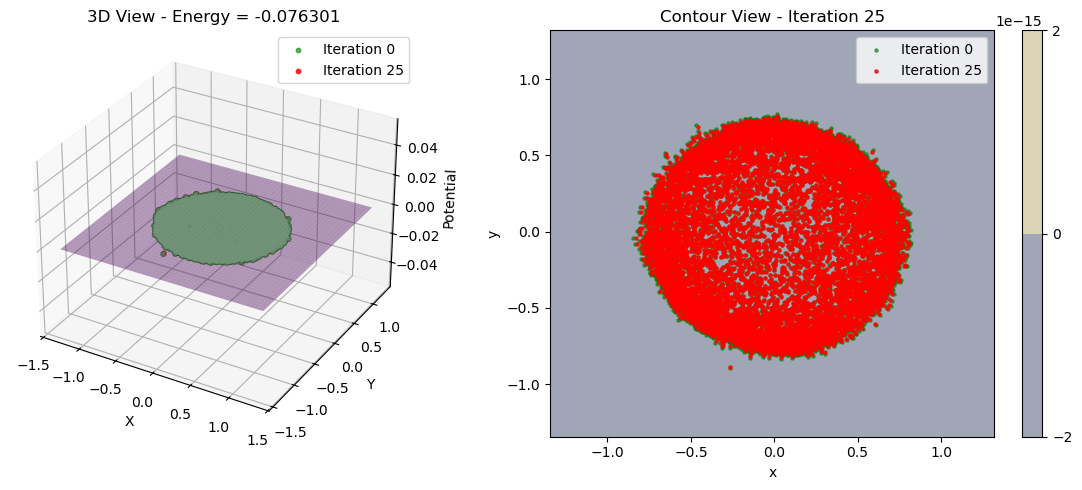

Iter   50 | Energy: -7.702887e-02 | Residual: 1.005688e-04 | 


In [ ]:
current_params, history = anderson_method(
    parametric_model, 
    n_samples, 
    z_samples, 
    G_mat_flow, 
    potential,
    solver=solver,
    initial_params=init_params,
    n_iterations=max_iterations, 
    step_size=h, 
    memory_size=m, 
    relaxation=beta, 
    solver_tol= tolerance,
    l2_reg_gamma=l2_reg_gamma,
    plot_intermediate=True,
    plot_frequency=25
)

In [10]:
samples_AA = parametric_model(samples = z_samples,params=current_params)

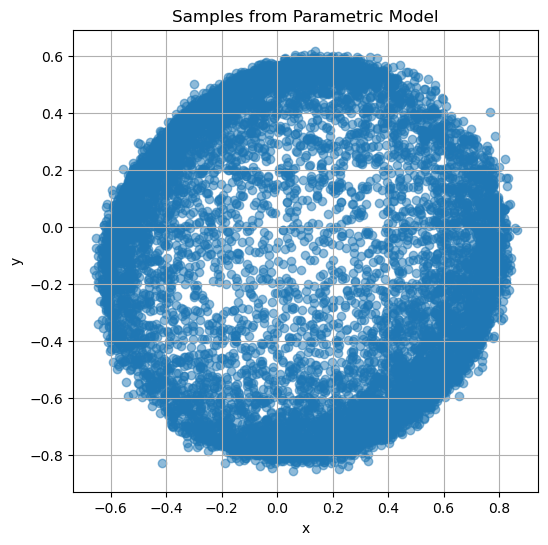

In [11]:


plt.figure(figsize=(6,6))   
plt.scatter(samples_AA[:, 0], samples_AA[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.show()

In [ ]:
# Define the parametric model
# dim = 2
parametric_model_gf = ParametricModel(
    parametric_map="resnet",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 2, 50],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.1, 
    ref_density="gaussian",
    scale_factor=5e-1,
)
# _,init_params = nnx.split(parametric_model)


In [ ]:


# Gradient flow parameters
h = 5e-3 # Time step size2
# max_iterations = 500
# tolerance = 1e-6
# n_samples = 10_000  # Monte Carlo sample size


key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, dim))

G_mat_flow = G_matrix(parametric_model_gf)

solver= 'cg'



Gradient Flow Progress:   0%|          | 0/3000 [00:00<?, ?it/s]

2026-01-30 19:48:13.559864: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
Gradient Flow Progress:   8%|▊         | 250/3000 [06:45<1:11:12,  1.55s/it, Energy=-0.075866, Linear=0.000000, Internal=0.000000, Interaction=-0.075866]

Iter 250: Energy = -0.075866, Grad norm: 9.46e-02


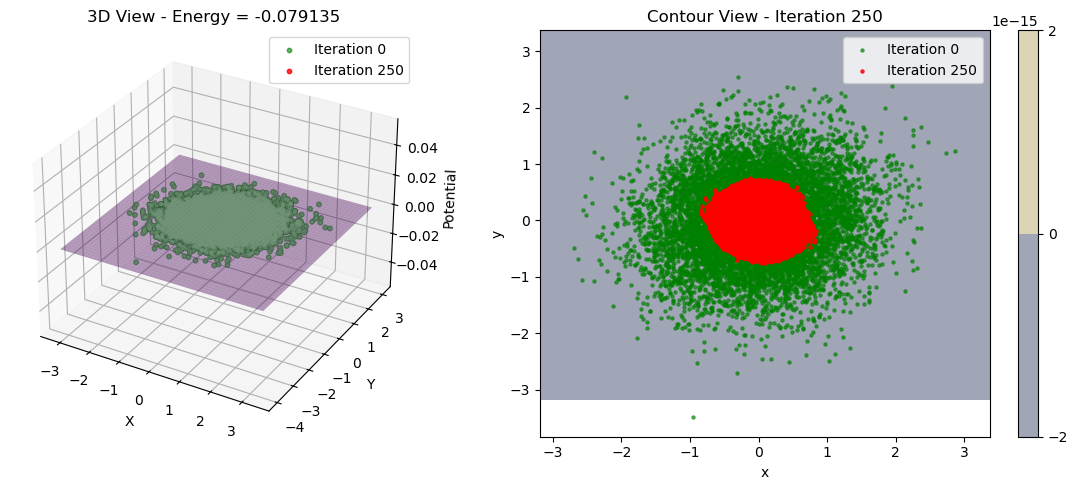

Gradient Flow Progress:  17%|█▋        | 500/3000 [13:20<1:06:30,  1.60s/it, Energy=-0.079702, Linear=0.000000, Internal=0.000000, Interaction=-0.079702]

Iter 500: Energy = -0.079702, Grad norm: 5.52e-02


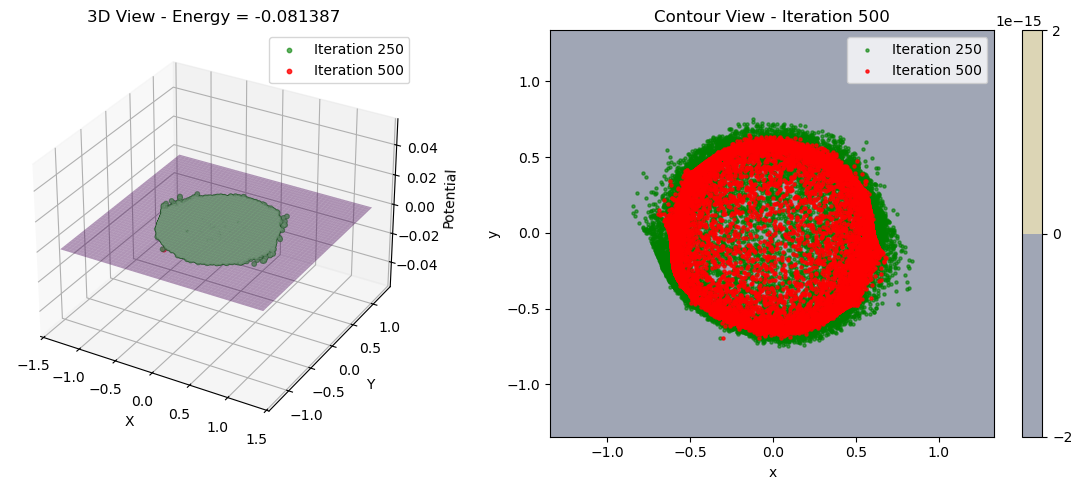

Gradient Flow Progress:  25%|██▌       | 750/3000 [20:05<59:48,  1.59s/it, Energy=-0.081656, Linear=0.000000, Internal=0.000000, Interaction=-0.081656]  

Iter 750: Energy = -0.081656, Grad norm: 1.07e-01


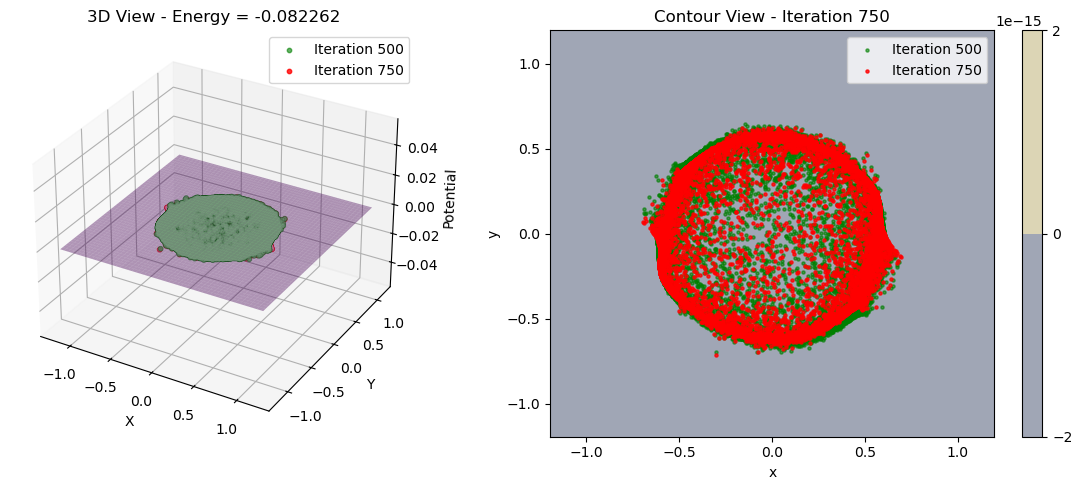

Gradient Flow Progress:  33%|███▎      | 1000/3000 [26:50<53:14,  1.60s/it, Energy=-0.088294, Linear=0.000000, Internal=0.000000, Interaction=-0.088294] 

Iter 1000: Energy = -0.088294, Grad norm: 4.53e-02


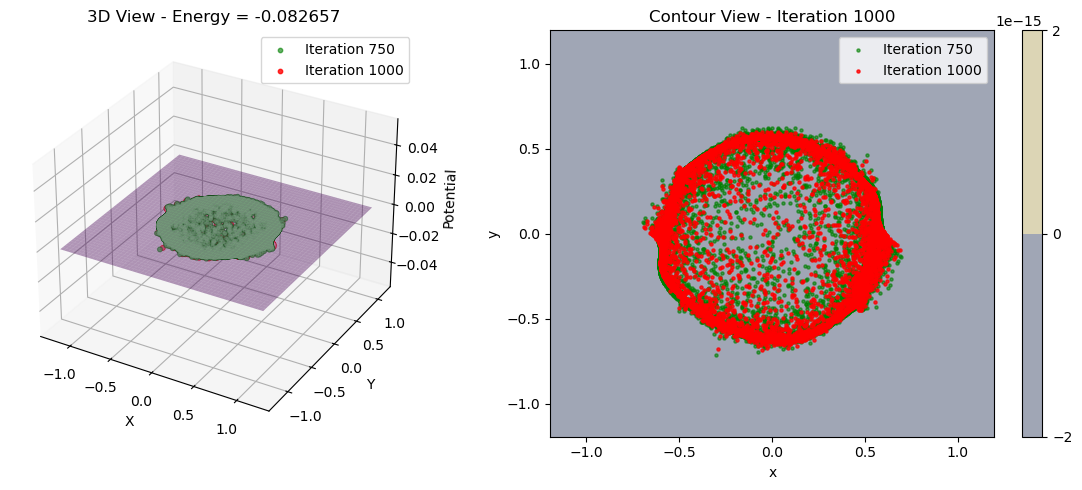

Gradient Flow Progress:  42%|████▏     | 1250/3000 [33:31<46:16,  1.59s/it, Energy=-0.081721, Linear=0.000000, Internal=0.000000, Interaction=-0.081721]  

Iter 1250: Energy = -0.081721, Grad norm: 9.15e-02


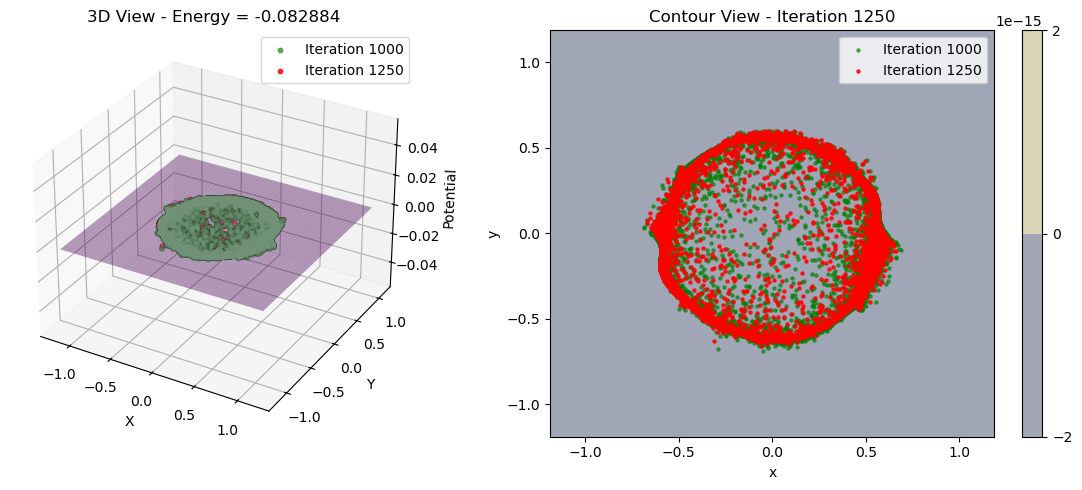

Gradient Flow Progress:  50%|█████     | 1500/3000 [40:15<39:18,  1.57s/it, Energy=-0.085318, Linear=0.000000, Internal=0.000000, Interaction=-0.085318]  

Iter 1500: Energy = -0.085318, Grad norm: 6.71e-02


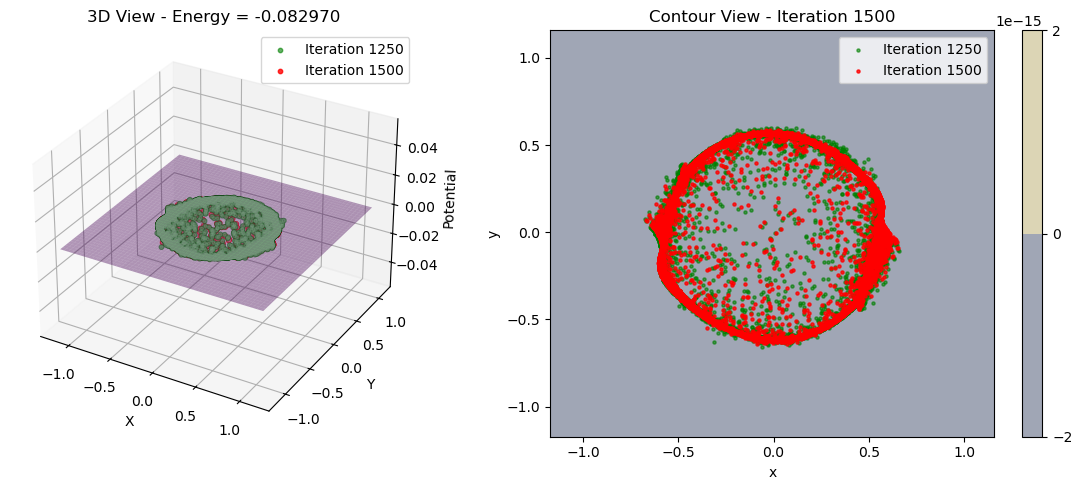

Gradient Flow Progress:  58%|█████▊    | 1750/3000 [46:52<32:53,  1.58s/it, Energy=-0.078858, Linear=0.000000, Internal=0.000000, Interaction=-0.078858]

Iter 1750: Energy = -0.078858, Grad norm: 1.11e-01


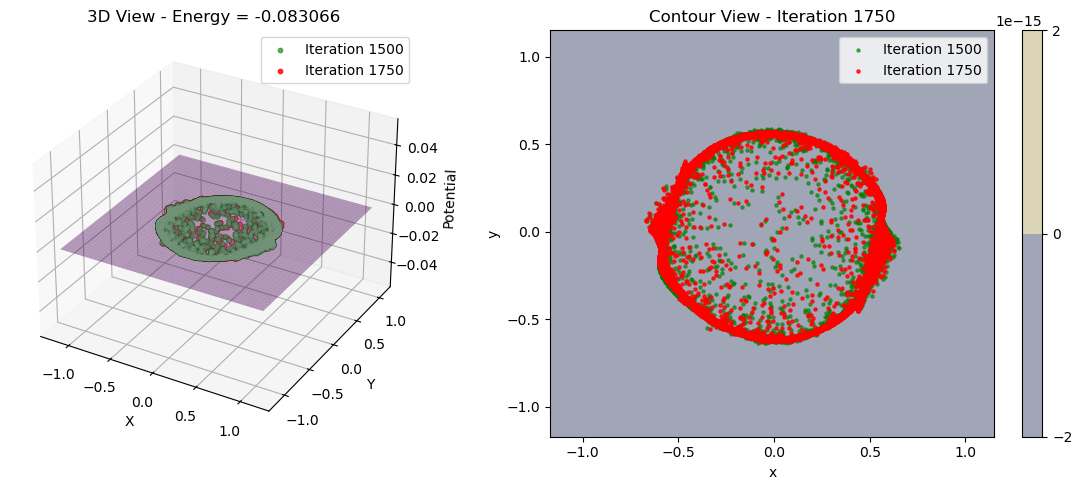

Gradient Flow Progress:  67%|██████▋   | 2000/3000 [53:33<25:23,  1.52s/it, Energy=-0.080821, Linear=0.000000, Internal=0.000000, Interaction=-0.080821]  

Iter 2000: Energy = -0.080821, Grad norm: 1.04e-01


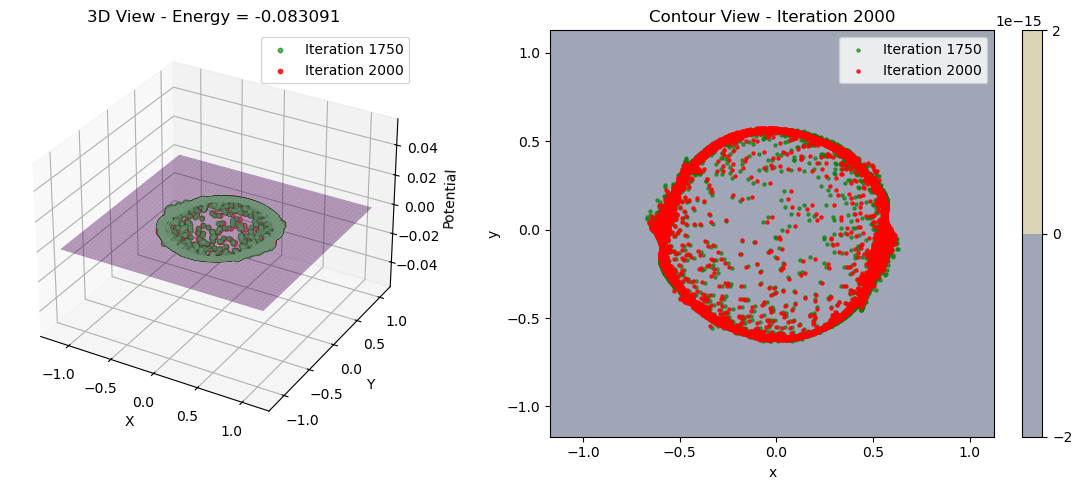

Gradient Flow Progress:  75%|███████▌  | 2250/3000 [1:00:18<20:02,  1.60s/it, Energy=-0.082344, Linear=0.000000, Internal=0.000000, Interaction=-0.082344]

Iter 2250: Energy = -0.082344, Grad norm: 1.27e-01


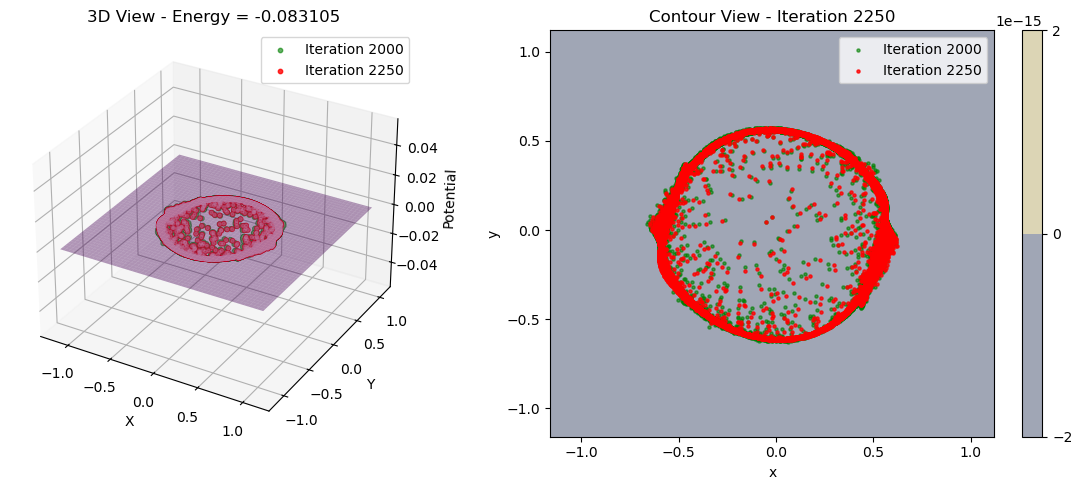

Gradient Flow Progress:  83%|████████▎ | 2500/3000 [1:06:56<13:16,  1.59s/it, Energy=-0.091618, Linear=0.000000, Internal=0.000000, Interaction=-0.091618]

Iter 2500: Energy = -0.091618, Grad norm: 9.17e-02


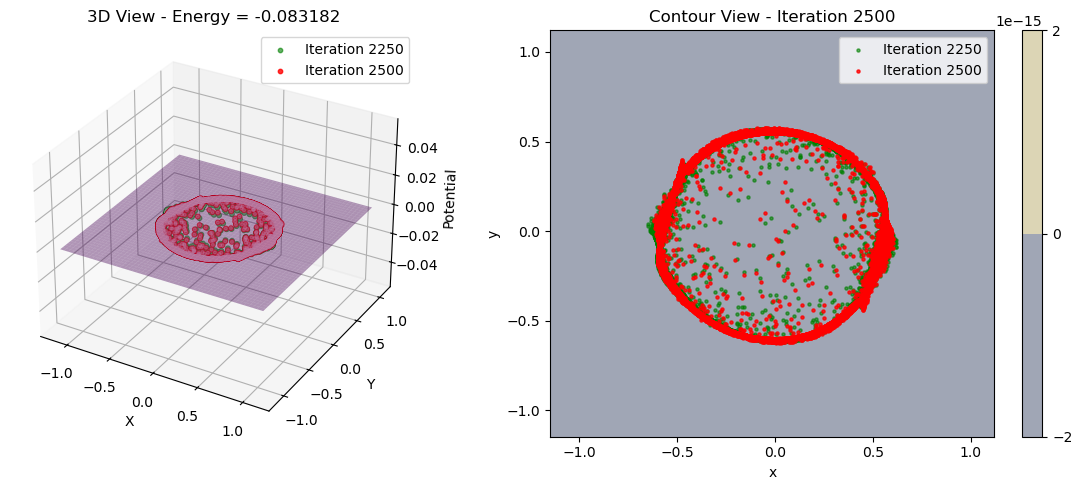

Gradient Flow Progress:  92%|█████████▏| 2750/3000 [1:13:43<06:40,  1.60s/it, Energy=-0.081413, Linear=0.000000, Internal=0.000000, Interaction=-0.081413]

Iter 2750: Energy = -0.081413, Grad norm: 8.43e-02


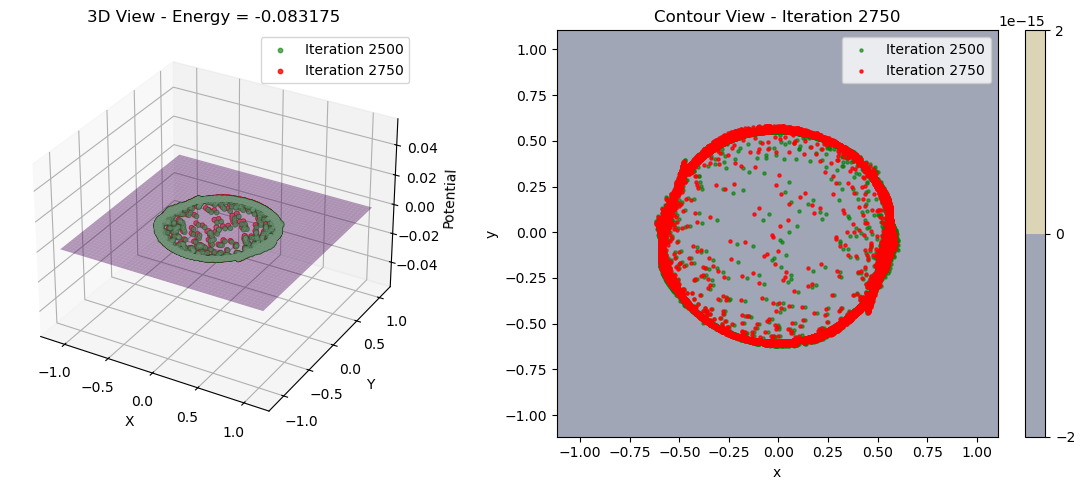

Gradient Flow Progress: 100%|█████████▉| 2998/3000 [1:20:27<00:03,  1.61s/it, Energy=-0.077671, Linear=0.000000, Internal=0.000000, Interaction=-0.077671]

Iter 2998: Energy = -0.077671, Grad norm: 7.49e-02


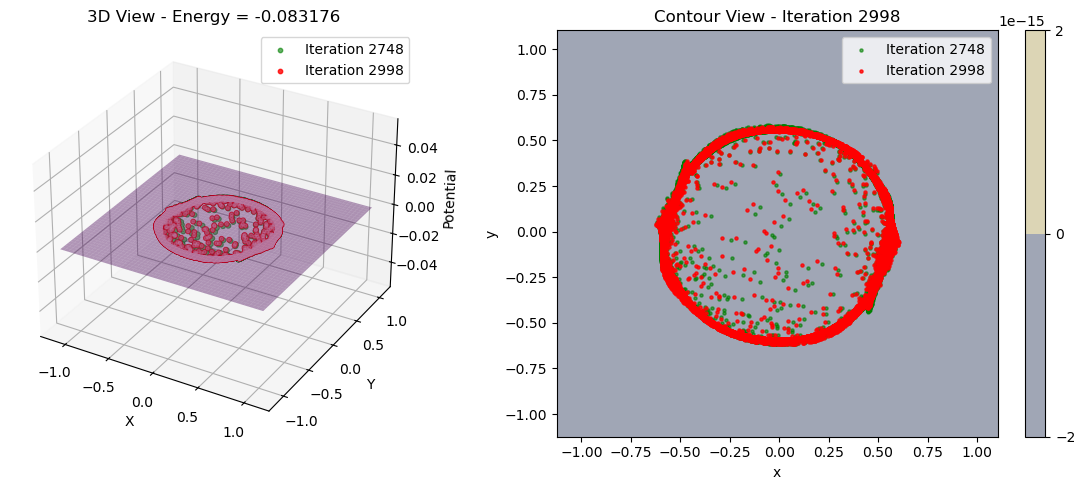

Gradient Flow Progress: 100%|██████████| 3000/3000 [1:20:30<00:00,  1.61s/it, Energy=-0.086227, Linear=0.000000, Internal=0.000000, Interaction=-0.086227]



=== Integration Complete ===
Total iterations:    3000
Initial energy:      1.089283
Final energy:        -0.083175
Total decrease:      1.172459
Reduction ratio:     -0.0764
Final param norm:    6.910990


In [ ]:


results = run_gradient_flow(
    parametric_model_gf, z_samples, G_mat_flow,
    potential
    ,solver=solver,
    h=h, max_iterations=max_iterations, tolerance=tolerance,
    progress_every=250,regularization=1e-4
)



results.keys()

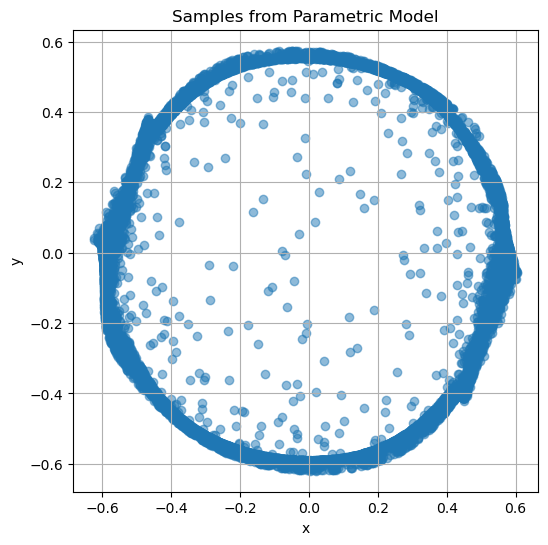

In [ ]:
samples = results['final_parametric_model'](samples = z_samples)

plt.figure(figsize=(6,6))   
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.show()

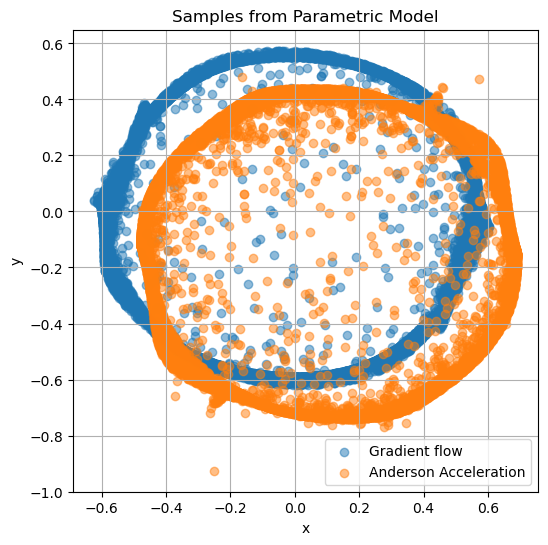

In [ ]:
plt.figure(figsize=(6,6))   
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label = 'Gradient flow')
plt.scatter(samples_AA[:, 0], samples_AA[:, 1], alpha=0.5, label = 'Anderson Acceleration')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.legend()
plt.show()

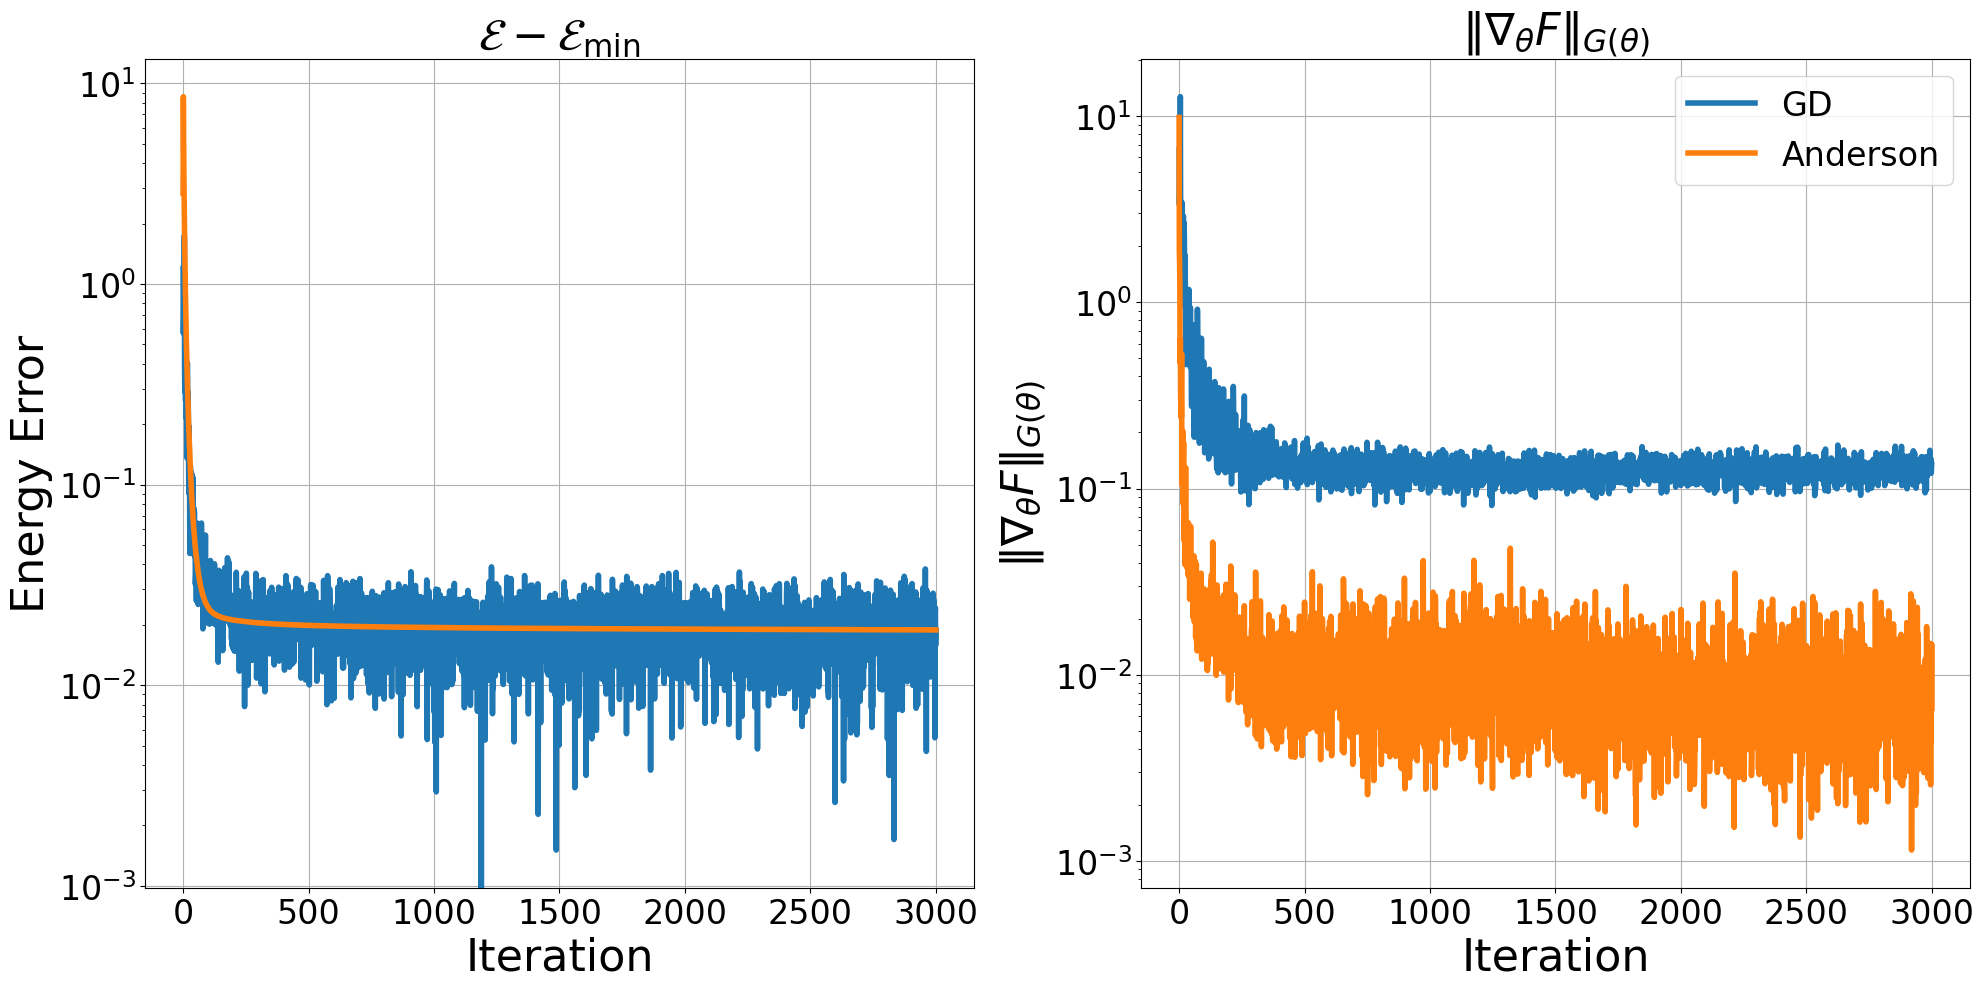

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,10))
ax = axs[0]
e_gd = results["energy_history"]
e_gd = jnp.array(e_gd)
e_am = history["energies"]
e_am = jnp.array(e_am)
e_min = jnp.min(jnp.concatenate((e_gd, e_am))) - 1e-10
e_gd -= e_min  # so that we can safely plot in log scale
e_am -= e_min
ax.plot(e_gd, label='GD', linewidth=4)
ax.plot(e_am, label='Anderson', linewidth=4)
ax.tick_params(axis='both', which='major', labelsize=24)
ax.set_yscale("log")
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel('Energy Error',fontsize=32)
# ax.set_ylim(1e-2, None)
ax.grid()
ax.set_title(r'$\mathcal{E} - \mathcal{E}_{\text{min}}$', fontsize=32)

ax = axs[1]

ax.plot(results['riemann_grad_norm_history'], label='GD',linewidth=4)
ax.plot(history['riemann_grad_history'], label='Anderson', linewidth=4)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=24)
ax.grid()
ax.set_title(r"$\| \nabla_\theta F\|_{G(\theta)}$", fontsize=32)
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel(r'$\| \nabla_\theta F\|_{G(\theta)}$', fontsize=32)

# ax = axs[2]
# ax.plot(history['euclid_grad_norm_history'], label='GD')
# ax.set_yscale('log')
# ax.grid()
# ax.set_title(r"$\| \nabla_\theta F\|_2$")

axs[-1].legend(fontsize=24)

fig.tight_layout()
# fig.savefig('GD_vs_AM.pdf')